# 미디어 활용(12~14p) EDA 리포트 노트북
이 노트북은 **미디어 활용 파트(49개 X)**를 대상으로, `is_churned`와의 관계를 발표용으로 **표/그래프 중심**으로 정리합니다.

## 구성(발표 흐름)
1. 데이터 로드 & 범위 설정
2. 타깃(Y) 분포
3. 데이터 품질(결측/전원결측)
4. 온라인 활동 분포(0코드/바닥효과)
5. X끼리 상관 구조(분포 + 히트맵 + 강한 쌍)
6. X vs Y (상관 + 평균차이 Top)
7. 커뮤니티 활동(0코드) vs 이탈률
8. 요약 인사이트

> ⚠️ 경로는 본인 환경에 맞게 `DATA_PATH`만 수정하세요.

In [21]:

# 0) 환경 설정
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# 데이터 경로(Windows)
DATA_PATH = r"C:\Users\Playdata\Documents\workspace\twilkka-malkka-ml\00_data\01_interim\selected_data_2023.csv"

y_col = "is_churned"


## 1) 데이터 로드 & 분석 대상 컬럼(미디어 49개) 설정

In [37]:

df = pd.read_csv(DATA_PATH, low_memory=False)

media_42 = [
    # 온라인 활동(문21)
    "p__d14002","p__d14004","p__d14005","p__d14008","p__d14011",

    # PC 활용(문22)
    "p__d25040","p__d25041","p__d25042","p__d25045","p__d25047","p__d25048","p__d25049",
    "p__d25052","p__d25053","p__d25056","p__d25057","p__d25058","p__d25060",

    # 스마트기기 활용(문23)
    "p__d25062","p__d25064","p__d25065","p__d25066","p__d25070","p__d25072","p__d25073",
    "p__d25076","p__d25077","p__d25080","p__d25081","p__d25082","p__d25083","p__d25085",

    # 프라이버시 침해 우려(문24)
    "p__d23003","p__d23005","p__d23006","p__d23007","p__d23008",

    # 미디어(문25)
    "p__n01038","p__n01041","p__n01042","p__n01043","p__n01047"
]

exist_cols = [c for c in media_42 if c in df.columns]
missing_cols = [c for c in media_42 if c not in df.columns]

media_df = df[exist_cols].copy()

print("원본 df shape:", df.shape)
print("미디어(42 기준) 존재 컬럼 수:", len(exist_cols))
print("미디어 df shape:", media_df.shape)
if missing_cols:
    print("\n[주의] CSV에 없는 컬럼:", missing_cols)

media_df.head()


원본 df shape: (2280, 1522)
미디어(49 기준) 존재 컬럼 수: 42
미디어 df shape: (2280, 42)


,p__d14002,p__d14004,p__d14005,p__d14008,p__d14011,p__d25040,p__d25041,p__d25042,p__d25045,p__d25047,p__d25048,p__d25049,p__d25052,p__d25053,p__d25056,p__d25057,p__d25058,p__d25060,p__d25062,p__d25064,p__d25065,p__d25066,p__d25070,p__d25072,p__d25073,p__d25076,p__d25077,p__d25080,p__d25081,p__d25082,p__d25083,p__d25085,p__d23003,p__d23005,p__d23006,p__d23007,p__d23008,p__n01038,p__n01041,p__n01042,p__n01043,p__n01047
0,0.0,0.0,1.0,1.0,1.0,3.0,3.0,3.0,4.0,2.0,4.0,3.0,4.0,2.0,2.0,2.0,2.0,1.0,5,5,5,3,4,4,3,3,2,3,3,2,2,2,5,5,4,5,5,3.0,4.0,3.0,3.0,3.0
1,1.0,1.0,1.0,1.0,1.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,3.0,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,3,5,4,5,3.0,4.0,4.0,4.0,4.0
2,4.0,5.0,1.0,4.0,1.0,4.0,3.0,3.0,3.0,2.0,2.0,4.0,4.0,3.0,3.0,4.0,1.0,5.0,5,5,5,5,2,2,2,4,3,5,3,5,3,4,5,5,5,5,5,3.0,2.0,2.0,2.0,3.0
3,3.0,2.0,1.0,1.0,1.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5.0,5.0,5.0,5.0,5.0
4,1.0,1.0,1.0,1.0,1.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,4.0,4.0,4.0,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,3.0,3.0,3.0,4.0,4.0


## 2) 타깃(Y) 분포
이탈 여부(`is_churned`)의 클래스 분포를 확인합니다.

is_churned
0    1455
1     825
Name: count, dtype: int64


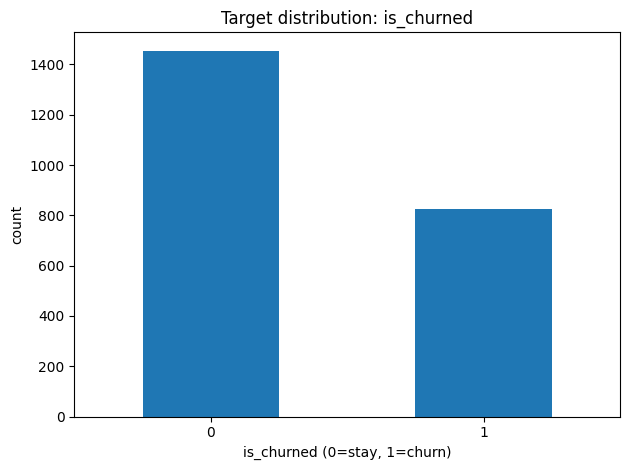

In [38]:

print(df[y_col].value_counts(dropna=False))

# bool이면 0/1로 변환
if df[y_col].dtype == bool:
    df[y_col] = df[y_col].astype(int)

plt.figure()
df[y_col].value_counts().sort_index().plot(kind="bar")
plt.title("Target distribution: is_churned")
plt.xlabel("is_churned (0=stay, 1=churn)")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 3) 데이터 품질(결측/전원결측/특수코드)
- 컬럼별 결측률, 값 범위(1~5인지), 유니크 수를 요약합니다.
- 0/99 같은 특수코드가 있는지 체크합니다.

In [59]:

special_candidates = [0, 7, 8, 9, 98, 99, 998, 999]

rows = []
for c in media_df.columns:
    s = media_df[c]
    row = {
        "col": c,
        "dtype": str(s.dtype),
        "n": len(s),
        "nonnull": int(s.notna().sum()),
        "na_rate(%)": round(s.isna().mean()*100, 2),
        "n_unique": int(s.nunique(dropna=True))
    }
    if pd.api.types.is_numeric_dtype(s):
        row["min"] = float(s.min()) if s.notna().any() else np.nan
        row["max"] = float(s.max()) if s.notna().any() else np.nan
        vc = s.value_counts(dropna=False)
        for v in special_candidates:
            row[f"cnt_{v}"] = int(vc.get(v, 0))
    rows.append(row)

summary_df = pd.DataFrame(rows).sort_values(["na_rate(%)", "n_unique"], ascending=[False, True])

summary_df.head(30)


,col,dtype,n,nonnull,na_rate(%),n_unique,min,max,cnt_0,cnt_7,cnt_8,cnt_9,cnt_98,cnt_99,cnt_998,cnt_999
5,p__d25040,float64,2280,2280,0.0,5,1.0,5.0,0,0,0,0,0,0,0,0
6,p__d25041,float64,2280,2280,0.0,5,1.0,5.0,0,0,0,0,0,0,0,0
7,p__d25042,float64,2280,2280,0.0,5,1.0,5.0,0,0,0,0,0,0,0,0
8,p__d25045,float64,2280,2280,0.0,5,1.0,5.0,0,0,0,0,0,0,0,0
9,p__d25047,float64,2280,2280,0.0,5,1.0,5.0,0,0,0,0,0,0,0,0
10,p__d25048,float64,2280,2280,0.0,5,1.0,5.0,0,0,0,0,0,0,0,0
11,p__d25049,float64,2280,2280,0.0,5,1.0,5.0,0,0,0,0,0,0,0,0
12,p__d25052,float64,2280,2280,0.0,5,1.0,5.0,0,0,0,0,0,0,0,0
13,p__d25053,float64,2280,2280,0.0,5,1.0,5.0,0,0,0,0,0,0,0,0
14,p__d25056,float64,2280,2280,0.0,5,1.0,5.0,0,0,0,0,0,0,0,0


## 4) 온라인 활동 문항 분포(0코드/바닥효과)

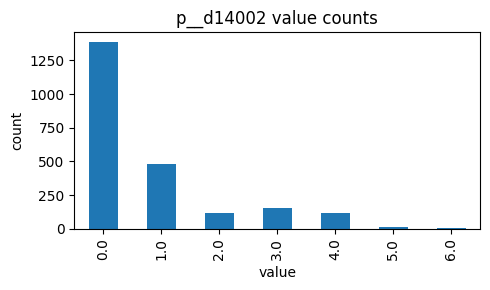

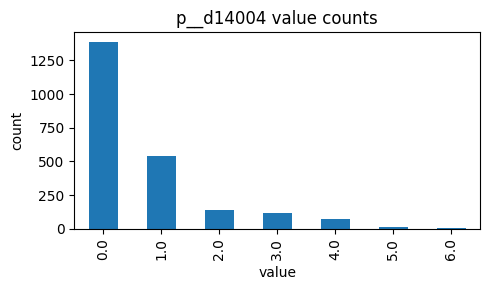

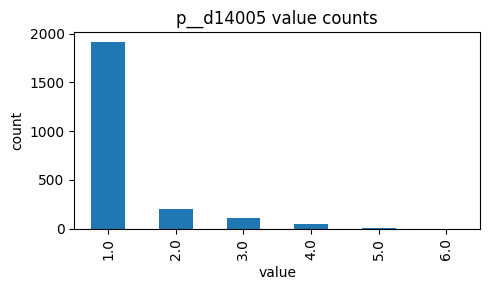

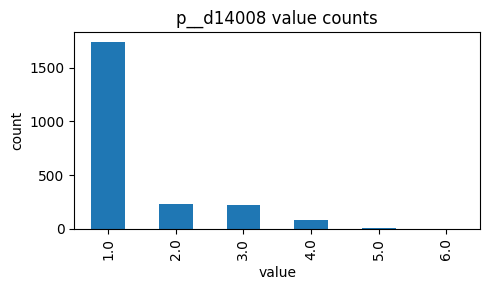

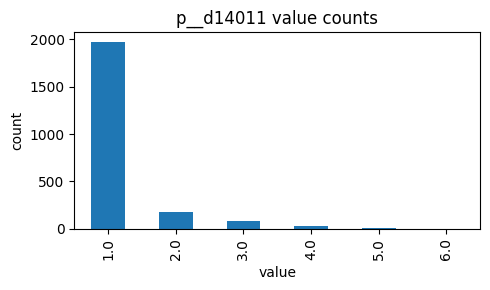

In [41]:

online_cols = ["p__d14002","p__d14004","p__d14005","p__d14008","p__d14011",]
online_cols = [c for c in online_cols if c in media_df.columns]

for c in online_cols:
    vc = media_df[c].value_counts(dropna=False).sort_index()
    plt.figure(figsize=(5,3))
    vc.plot(kind="bar")
    plt.title(f"{c} value counts")
    plt.xlabel("value")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()


## 5) X끼리 상관 구조(Spearman)

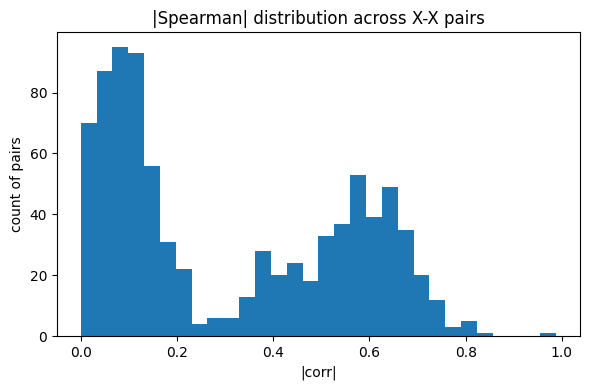

[전체 X-X 상관(대각선 제외)]
변수 수: 42
pair 개수: 1764
평균(corr): 0.3092169388151666
평균(|corr|): 0.31021832994600884
중앙값(|corr|): 0.19577122590593038
90퍼센타일(|corr|): 0.6504182381123733
95퍼센타일(|corr|): 0.6899115544875305


In [42]:

num_media = media_df.select_dtypes(include=[np.number])
corr = num_media.corr(method="spearman")

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
vals = upper.stack()

plt.figure(figsize=(6,4))
plt.hist(vals.abs(), bins=30)
plt.title("|Spearman| distribution across X-X pairs")
plt.xlabel("|corr|")
plt.ylabel("count of pairs")
plt.tight_layout()
plt.show()

print("[전체 X-X 상관(대각선 제외)]")
print("변수 수:", corr.shape[0])
print("pair 개수:", len(vals))
print("평균(corr):", float(vals.mean()))
print("평균(|corr|):", float(vals.abs().mean()))
print("중앙값(|corr|):", float(vals.abs().median()))
print("90퍼센타일(|corr|):", float(vals.abs().quantile(0.90)))
print("95퍼센타일(|corr|):", float(vals.abs().quantile(0.95)))


### 5-1) 강한 상관쌍(|corr| ≥ 0.7) Top 표

In [43]:

threshold = 0.7
strong = vals[vals.abs() >= threshold]

print(f"[강한 상관쌍만 |corr| >= {threshold}]")
print("pair 개수:", int(len(strong)))
if len(strong) > 0:
    print("평균(|corr|):", float(strong.abs().mean()))
    print("최대 |corr|:", float(strong.abs().max()))

strong_df = strong.reset_index()
strong_df.columns = ["x1", "x2", "spearman_corr"]
strong_df = strong_df.sort_values("spearman_corr", key=lambda s: s.abs(), ascending=False)

strong_df.head(20)


[강한 상관쌍만 |corr| >= 0.7]
pair 개수: 35
평균(|corr|): 0.7518277189393483
최대 |corr|: 0.9882382851113077


,x1,x2,spearman_corr
0,p__d14002,p__d14004,0.988238
8,p__d25052,p__d25053,0.853717
13,p__d25057,p__d25058,0.821608
16,p__d25058,p__d25060,0.819542
19,p__d25076,p__d25077,0.817593
28,p__d25083,p__d25085,0.801448
10,p__d25056,p__d25057,0.798508
14,p__d25057,p__d25060,0.784769
5,p__d25048,p__d25049,0.777542
23,p__d25081,p__d25082,0.769256


## 스코어화

In [49]:
import numpy as np
import pandas as pd

# =========================
# 0) 스코어화 그룹 정의
# =========================
online_cols = ["p__d14002","p__d14004","p__d14005","p__d14008","p__d14011"]

pc_cols = ["p__d25040","p__d25041","p__d25042","p__d25045","p__d25047","p__d25048","p__d25049",
           "p__d25052","p__d25053","p__d25056","p__d25057","p__d25058","p__d25060"]

smart_cols = ["p__d25062","p__d25064","p__d25065","p__d25066","p__d25070","p__d25072","p__d25073",
              "p__d25076","p__d25077","p__d25080","p__d25081","p__d25082","p__d25083","p__d25085"]

privacy_cols = ["p__d23003","p__d23005","p__d23006","p__d23007","p__d23008"]

media_cols = ["p__n01038","p__n01041","p__n01042","p__n01043","p__n01047"]

def exist_only(cols):
    return [c for c in cols if c in media_df.columns]

groups = {
    "온라인활동(문21)": exist_only(online_cols),
    "PC_활용(문22)": exist_only(pc_cols),
    "스마트기기_활용(문23)": exist_only(smart_cols),
    "프라이버시_우려(문24)": exist_only(privacy_cols),
    "정보판단/리터러시(문25)": exist_only(media_cols),
}

# =========================
# 1) 크론바흐 알파 함수
# =========================
def cronbach_alpha(df_items: pd.DataFrame) -> float:
    """
    Cronbach's alpha (listwise 삭제)
    - df_items: 컬럼=문항, 행=응답자
    """
    x = df_items.dropna(axis=0)
    k = x.shape[1]
    if k < 2 or x.shape[0] < 2:
        return np.nan
    item_var = x.var(axis=0, ddof=1)
    total_var = x.sum(axis=1).var(ddof=1)
    if total_var == 0:
        return np.nan
    return float((k / (k - 1)) * (1 - item_var.sum() / total_var))

def item_total_corr(df_items: pd.DataFrame) -> pd.Series:
    """
    각 문항과 (해당 문항 제외 총점) 간 Spearman 상관
    """
    x = df_items.dropna(axis=0)
    out = {}
    for c in x.columns:
        total_wo = x.drop(columns=[c]).sum(axis=1)
        out[c] = x[c].corr(total_wo, method="spearman")
    return pd.Series(out).sort_values(ascending=False)

def alpha_if_dropped(df_items: pd.DataFrame) -> pd.Series:
    """
    문항 하나씩 제거했을 때 alpha
    """
    x = df_items.dropna(axis=0)
    out = {}
    for c in x.columns:
        out[c] = cronbach_alpha(x.drop(columns=[c]))
    return pd.Series(out).sort_values(ascending=False)

# =========================
# 2) 그룹별 스코어화 타당성 점검 리포트
# =========================
report_rows = []

for gname, cols in groups.items():
    items = media_df[cols].copy()

    # 전원결측/상수열 제거
    non_allnan = [c for c in items.columns if items[c].notna().any()]
    items = items[non_allnan]
    non_constant = [c for c in items.columns if items[c].nunique(dropna=True) > 1]
    items = items[non_constant]

    n_raw = len(items)
    n_listwise = int(items.dropna(axis=0).shape[0])
    k = int(items.shape[1])

    a = cronbach_alpha(items) if k >= 2 else np.nan
    mean_abs_corr = np.nan
    if k >= 2:
        corr = items.dropna().corr(method="spearman")
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
        mean_abs_corr = float(upper.abs().mean()) if len(upper) else np.nan

    report_rows.append({
        "group": gname,
        "k(문항수)": k,
        "N(원본)": n_raw,
        "N(리스트와이즈)": n_listwise,
        "Cronbach_alpha": a,
        "mean(|spearman|) within": mean_abs_corr
    })

report = pd.DataFrame(report_rows).sort_values("Cronbach_alpha", ascending=False)
report

,group,k(문항수),N(원본),N(리스트와이즈),Cronbach_alpha,mean(|spearman|) within
1,PC_활용(문22),13,2280,2280,0.962846,0.653816
2,스마트기기_활용(문23),14,2280,2280,0.944280,0.568002
4,정보판단/리터러시(문25),5,2280,2280,0.927295,0.706256
3,프라이버시_우려(문24),5,2280,2280,0.918107,0.647943
0,온라인활동(문21),5,2280,2280,0.836961,0.514278


In [50]:
for gname, cols in groups.items():
    items = media_df[cols].copy()

    # 전원 결측 컬럼 제거
    items = items[[c for c in items.columns if items[c].notna().any()]]

    # 상수 컬럼 제거
    items = items[[c for c in items.columns if items[c].nunique(dropna=True) > 1]]

    print(f"\n\n===== {gname} =====")
    print("k:", items.shape[1], " / listwise N:", items.dropna().shape[0])
    print("alpha:", cronbach_alpha(items))

    print("\n[item-total corr (spearman)]")
    display(item_total_corr(items).to_frame("item_total_corr"))

    print("\n[alpha if item dropped]")
    display(alpha_if_dropped(items).to_frame("alpha_if_dropped"))



===== 온라인활동(문21) =====
k: 5  / listwise N: 2280
alpha: 0.8369605042133098

[item-total corr (spearman)]


,item_total_corr
p__d14004,0.829607
p__d14002,0.822415
p__d14005,0.538686
p__d14008,0.507463
p__d14011,0.507094



[alpha if item dropped]


,alpha_if_dropped
p__d14008,0.828422
p__d14011,0.825216
p__d14005,0.815505
p__d14002,0.771639
p__d14004,0.756329




===== PC_활용(문22) =====
k: 13  / listwise N: 2280
alpha: 0.9628462751477892

[item-total corr (spearman)]


...

,alpha_if_dropped
p__d23006,0.903125
p__d23003,0.902716
p__d23007,0.900008
p__d23005,0.897679
p__d23008,0.894813




===== 정보판단/리터러시(문25) =====
k: 5  / listwise N: 2280
alpha: 0.9272951907487696

[item-total corr (spearman)]


,item_total_corr
p__n01041,0.810350
p__n01042,0.800868
p__n01043,0.798217
p__n01047,0.795865
p__n01038,0.785198



[alpha if item dropped]


,alpha_if_dropped
p__n01038,0.913147
p__n01047,0.911317
p__n01043,0.910883
p__n01042,0.909551
p__n01041,0.908655


,count,mean,std,min,max,na_rate(%)
online_score,2280.0,1.069737,0.721193,0.6,6.0,0.0
pc_score,2280.0,4.030229,0.907060,1.0,5.0,0.0
smart_score,2280.0,4.301065,0.705961,1.0,5.0,0.0
privacy_score,2280.0,3.988684,0.868155,1.0,5.0,0.0
media_score,2280.0,3.307807,0.883117,1.0,5.0,0.0


,spearman_corr_with_is_churned
media_score,-0.144346
privacy_score,-0.127476
pc_score,-0.087589
online_score,-0.061359
smart_score,-0.057724


,mean_y0,mean_y1,diff(y1-y0)
media_score,3.406323,3.134061,-0.272262
privacy_score,4.069278,3.846545,-0.222733
pc_score,4.098916,3.909091,-0.189825
smart_score,4.339568,4.233160,-0.106408
online_score,1.091959,1.030545,-0.061413


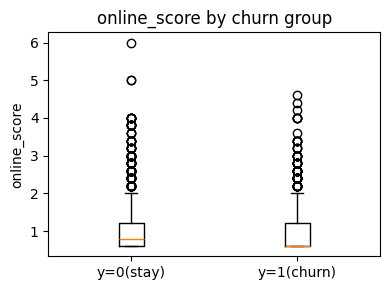

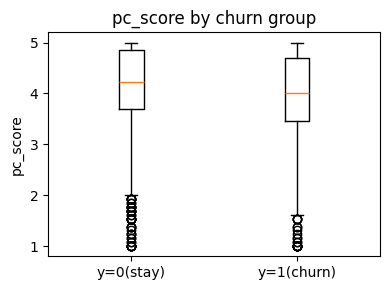

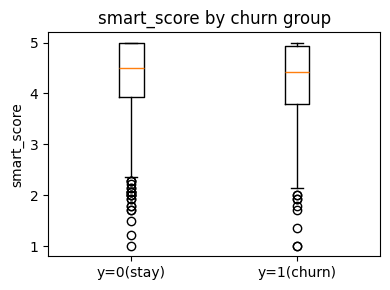

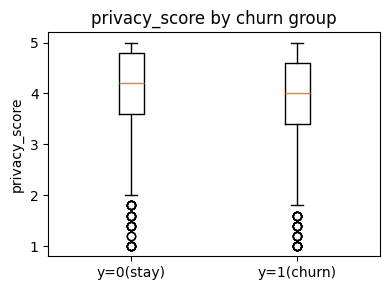

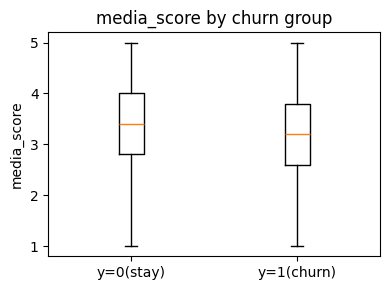

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) 스코어 생성(평균) - 결측은 있는 경우 자동으로 제외하고 평균냄(skipna=True)
score_df = pd.DataFrame(index=df.index)
score_df["is_churned"] = df[y_col].astype(int)

score_df["online_score"] = media_df[exist_only(online_cols)].mean(axis=1, skipna=True)
score_df["pc_score"] = media_df[exist_only(pc_cols)].mean(axis=1, skipna=True)
score_df["smart_score"] = media_df[exist_only(smart_cols)].mean(axis=1, skipna=True)
score_df["privacy_score"] = media_df[exist_only(privacy_cols)].mean(axis=1, skipna=True)
score_df["media_score"] = media_df[exist_only(media_cols)].mean(axis=1, skipna=True)

# 2) 스코어 요약(분포/결측률)
score_cols = ["online_score", "pc_score", "smart_score", "privacy_score", "media_score"]

summary = score_df[score_cols].agg(["count", "mean", "std", "min", "max"]).T
summary["na_rate(%)"] = (1 - score_df[score_cols].count() / len(score_df)) * 100
display(summary)

# 3) 스코어 vs Y 상관(Spearman)  *이진 Y라서 부호 해석 쉬움*
corrs = score_df[["is_churned"] + score_cols].dropna().corr(method="spearman")["is_churned"].drop("is_churned")
corrs = corrs.sort_values(key=lambda s: s.abs(), ascending=False)
display(corrs.to_frame("spearman_corr_with_is_churned"))

# 4) 이탈/비이탈 그룹 평균 차이 표
group_means = score_df.groupby("is_churned")[score_cols].mean().T
group_means.columns = ["mean_y0", "mean_y1"]
group_means["diff(y1-y0)"] = group_means["mean_y1"] - group_means["mean_y0"]
display(group_means.sort_values("diff(y1-y0)"))

# 5) 발표용 박스플롯(스코어 vs churn)
for col in score_cols:
    tmp0 = score_df.loc[score_df["is_churned"] == 0, col].dropna()
    tmp1 = score_df.loc[score_df["is_churned"] == 1, col].dropna()

    plt.figure(figsize=(4, 3))
    plt.boxplot([tmp0, tmp1], tick_labels=["y=0(stay)", "y=1(churn)"])
    plt.title(f"{col} by churn group")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [58]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

import statsmodels.api as sm

# =========================
# 0) 분석 데이터 준비
# =========================
score_cols = ["online_score", "pc_score", "smart_score", "privacy_score", "media_score"]
data = score_df[["is_churned"] + score_cols].dropna().copy()

X = data[score_cols]
y = data["is_churned"].astype(int)

print("분석용 N:", len(data))
print("이탈률:", y.mean().round(4))

# =========================
# 1) 스코어끼리 상관(겹침) 확인
# =========================
score_corr = X.corr(method="spearman")
display(score_corr)

# 상관 상위쌍(대각선 제외)
pairs = (
    score_corr.where(np.triu(np.ones(score_corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .reset_index()
)
pairs.columns = ["score1", "score2", "spearman_corr"]
display(pairs)

# =========================
# 1-1) X와 y의 스피어만 상관계수
# =========================
from scipy.stats import spearmanr

rows = []

for c in score_cols:
    tmp = data[[c, "is_churned"]].dropna()
    rho, pval = spearmanr(tmp[c], tmp["is_churned"])
    rows.append({
        "variable": c,
        "spearman_corr_with_is_churned": rho,
        "p_value": pval,
        "N": len(tmp)
    })

xy_corr = (
    pd.DataFrame(rows)
    .sort_values("spearman_corr_with_is_churned", key=lambda s: s.abs(), ascending=False)
    .reset_index(drop=True)
)

display(xy_corr)

# =========================
# 2) 로지스틱 회귀: OR(오즈비) + p-value
#    - 단변량 OR: 각 스코어 하나씩
#    - 다변량 OR: 5개 같이
# =========================
def logistic_or_table(X_df, y_ser):
    """
    statsmodels Logit으로 OR, 95% CI, p-value 테이블 생성
    """
    X_sm = sm.add_constant(X_df)
    model = sm.Logit(y_ser, X_sm).fit(disp=0)

    params = model.params
    conf = model.conf_int()
    pvals = model.pvalues

    out = pd.DataFrame({
        "coef(beta)": params,
        "OR(exp(beta))": np.exp(params),
        "CI_low": np.exp(conf[0]),
        "CI_high": np.exp(conf[1]),
        "p_value": pvals
    })
    return model, out

# (2-1) 단변량
uni_rows = []
for c in score_cols:
    _, tab = logistic_or_table(X[[c]], y)
    row = tab.loc[c].copy()
    row.name = c
    uni_rows.append(row)

uni_or = pd.DataFrame(uni_rows).sort_values("OR(exp(beta))")
display(uni_or)

# (2-2) 다변량(5개 동시)
multi_model, multi_or = logistic_or_table(X, y)
display(multi_or)

# =========================
# 3) 예측력(AUC) - 스코어 5개로만
# =========================
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")

print(f"AUC (5-fold CV): mean={auc_scores.mean():.4f}, std={auc_scores.std():.4f}")
print("AUC each fold:", np.round(auc_scores, 4))

분석용 N: 2280
이탈률: 0.3618


,online_score,pc_score,smart_score,privacy_score,media_score
online_score,1.000000,0.190414,0.201483,0.103490,0.069179
pc_score,0.190414,1.000000,0.834873,0.133561,0.218743
smart_score,0.201483,0.834873,1.000000,0.092491,0.166991
privacy_score,0.103490,0.133561,0.092491,1.000000,0.495473
media_score,0.069179,0.218743,0.166991,0.495473,1.000000


,score1,score2,spearman_corr
0,pc_score,smart_score,0.834873
1,privacy_score,media_score,0.495473
2,pc_score,media_score,0.218743
3,online_score,smart_score,0.201483
4,online_score,pc_score,0.190414
5,smart_score,media_score,0.166991
6,pc_score,privacy_score,0.133561
7,online_score,privacy_score,0.103490
8,smart_score,privacy_score,0.092491
9,online_score,media_score,0.069179


,variable,spearman_corr_with_is_churned,p_value,N
0,media_score,-0.144346,4.360864e-12,2280
1,privacy_score,-0.127476,1.005801e-09,2280
2,pc_score,-0.087589,2.813463e-05,2280
3,online_score,-0.061359,3.378816e-03,2280
4,smart_score,-0.057724,5.832308e-03,2280


,coef(beta),OR(exp(beta)),CI_low,CI_high,p_value
media_score,-0.351050,0.703948,0.638075,0.776622,2.503090e-12
privacy_score,-0.291269,0.747315,0.677617,0.824182,5.511302e-09
pc_score,-0.226622,0.797222,0.726325,0.875039,1.850510e-06
smart_score,-0.210168,0.810448,0.719121,0.913375,5.703362e-04
online_score,-0.121534,0.885561,0.783741,1.000609,5.115388e-02


,coef(beta),OR(exp(beta)),CI_low,CI_high,p_value
const,1.372869,3.946658,2.049671,7.599323,0.000040
online_score,-0.037625,0.963074,0.848315,1.093358,0.561098
pc_score,-0.205913,0.813904,0.689767,0.960381,0.014739
smart_score,0.077720,1.080820,0.874210,1.336260,0.472752
privacy_score,-0.156903,0.854787,0.763797,0.956616,0.006289
media_score,-0.240402,0.786312,0.701844,0.880945,0.000034


AUC (5-fold CV): mean=0.5999, std=0.0199
AUC each fold: [0.5735 0.5796 0.6068 0.6161 0.6234]
